In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Kenya Climate Data - Exploratory Data Analysis

## Overview
This notebook analyzes daily climate data for Kenya from 2015 to 2026.
The data comes from NASA POWER satellite measurements recorded at Nairobi.

The goal is to clean the data, explore temperature and rainfall trends,
and extract insights that can support Ethiopia's position at COP32.

In [2]:
# Load Kenya climate data
df = pd.read_csv("../data/Kenya.csv")

# Add country column
df["Country"] = "Kenya"

# Convert YEAR and DOY into proper date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

print("Shape:", df.shape)
df.head()

Shape: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


## Data Loading
Kenya dataset contains 4108 daily observations recorded at Nairobi 
from January 2015 to March 2026. It has 12 columns covering temperature, 
rainfall, humidity, wind speed, pressure and specific humidity.
Each row represents one day of climate measurements.

In [3]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)

# Check missing values
missing = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

print("\nMissing values per column:")
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent.round(2)}))

Number of duplicate rows: 0

Missing values per column:
             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


## Data Cleaning
After replacing NASA's missing value code (-999) with NaN, 
the Kenya dataset showed no missing values in any column.
No duplicate rows were found either.

The dataset is complete and reliable for analysis.
All 4108 daily records are usable without any data loss.

df.describe().round(2)


## Summary Statistics

The describe() output shows key statistical properties of the dataset.

Temperature (T2M): The average daily temperature is 20.4°C which is 
warmer than Ethiopia. Nairobi sits at lower altitude than Addis Ababa 
which explains the higher temperatures. The maximum recorded temperature 
is 25.4°C.

Rainfall (PRECTOTCORR): The average daily rainfall is 1.47mm but the 
maximum reaches 51.65mm on single days. Most days are dry with occasional 
heavy bursts of rain.

Humidity (RH2M): Average humidity is 65.85% which is slightly lower 
than Ethiopia's 68.41%.

In [4]:
# Outlier detection
columns_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[columns_to_check].apply(stats.zscore)
outlier_mask = (z_scores.abs() > 3)
outlier_count = outlier_mask.any(axis=1).sum()

print("Total outlier rows detected:", outlier_count)
print("\nOutliers per column:")
print(outlier_mask.sum())

Total outlier rows detected: 121

Outliers per column:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


## Outlier Detection
Z-score analysis flagged 121 rows containing outlier values.

The majority of outliers (92) are in the PRECTOTCORR column (rainfall).
This is expected because heavy rainfall events are real climate events, 
not data errors.

Decision: We chose to KEEP all outliers because they represent real 
climate events important for this analysis. Removing them would hide 
extreme weather patterns which are critical for COP32 climate insights.

In [5]:
# Forward fill missing values for weather variables
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df[weather_cols] = df[weather_cols].ffill()

# Check no missing values remain
print("Missing values after forward fill:")
print(df[weather_cols].isna().sum())

Missing values after forward fill:
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
dtype: int64


## Missing Value Treatment
Forward-fill was applied to all weather variables after outlier detection.
Since Kenya had zero missing values, no changes were made to the data.
Forward-fill ensures that if any missing values existed they would be 
filled with the most recent valid observation which is appropriate for 
continuous daily weather measurements.

In [6]:
df.to_csv("../data/kenya_clean.csv", index=False)
print("Cleaned data saved")

Cleaned data saved


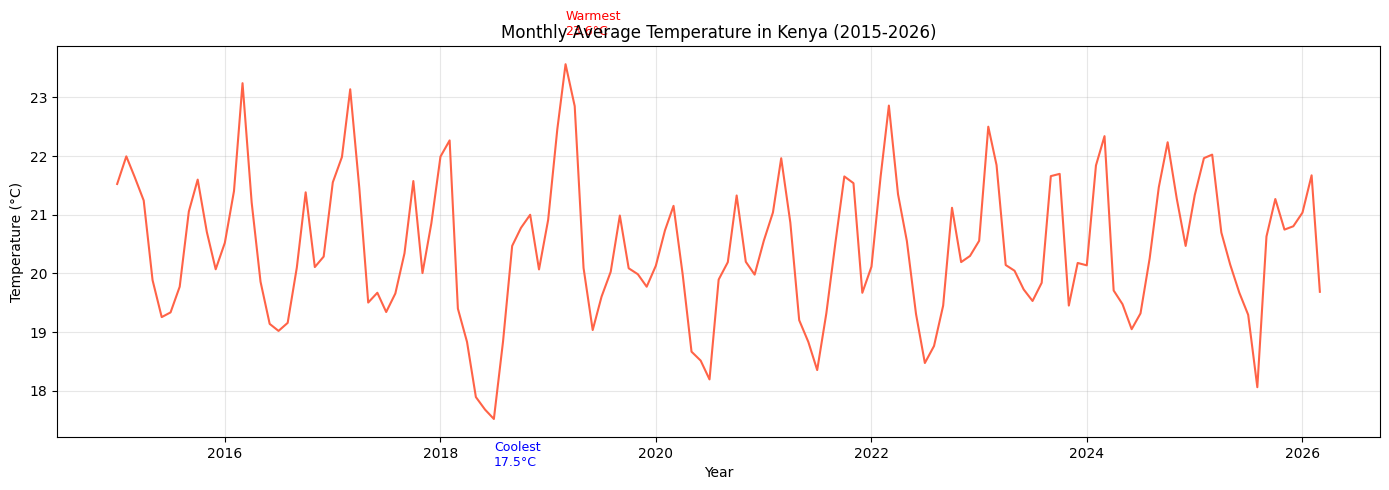

In [7]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato", linewidth=1.5)

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

# Annotate warmest and coolest
plt.annotate(f'Warmest\n{warmest["T2M"]:.1f}°C',
             xy=(warmest["Date"], warmest["T2M"]),
             xytext=(warmest["Date"], warmest["T2M"] + 0.5),
             fontsize=9, color="red")

plt.annotate(f'Coolest\n{coolest["T2M"]:.1f}°C',
             xy=(coolest["Date"], coolest["T2M"]),
             xytext=(coolest["Date"], coolest["T2M"] - 0.8),
             fontsize=9, color="blue")

plt.title("Monthly Average Temperature in Kenya (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trend (2015-2026)
The line chart shows monthly average temperature in Nairobi over 11 years.

Key observations:
- Kenya is significantly warmer than Ethiopia with a mean of 20.4°C 
  compared to Ethiopia's 16.1°C due to Nairobi's lower altitude
- Temperature follows a clear seasonal cycle every year
- The coolest months occur around July-August due to cloud cover 
  from the long rainy season
- A slight upward warming trend is visible over the full 11 year period
- This gradual warming is consistent with climate change projections 
  for East Africa

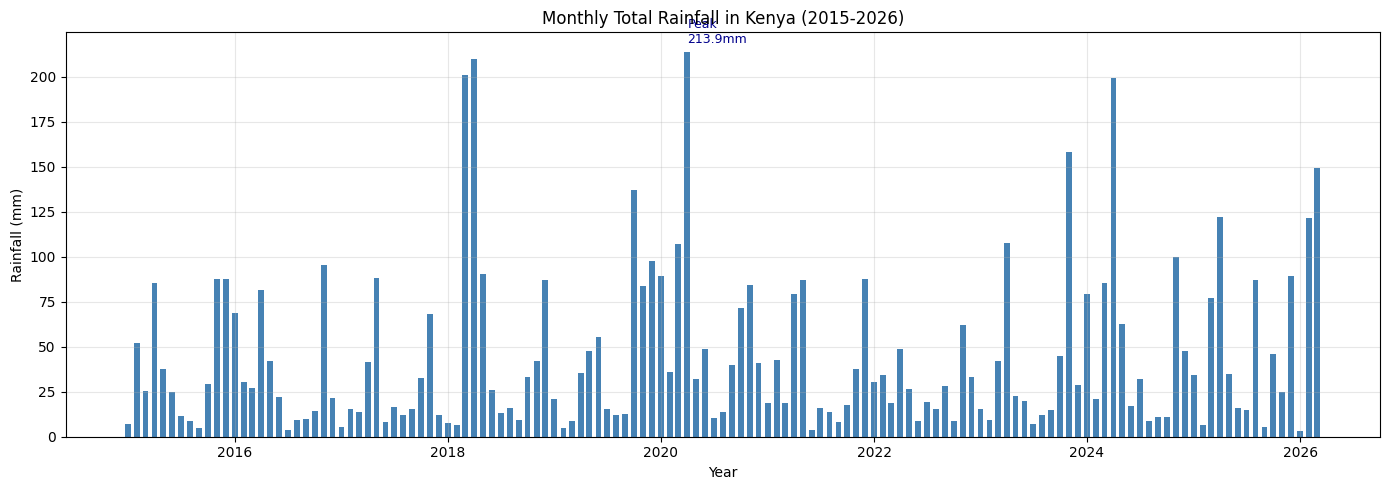

In [8]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_rain["Date"] = pd.to_datetime(monthly_rain[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_rain["Date"], monthly_rain["PRECTOTCORR"], color="steelblue", width=20)

# Find peak rainy month
peak = monthly_rain.loc[monthly_rain["PRECTOTCORR"].idxmax()]

# Annotate peak
plt.annotate(f'Peak\n{peak["PRECTOTCORR"]:.1f}mm',
             xy=(peak["Date"], peak["PRECTOTCORR"]),
             xytext=(peak["Date"], peak["PRECTOTCORR"] + 5),
             fontsize=9, color="darkblue")

plt.title("Monthly Total Rainfall in Kenya (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rainfall Trend (2015-2026)
The bar chart shows monthly total rainfall in Kenya over 11 years.

Key observations:
- Kenya has a bimodal rainfall pattern - two distinct rainy seasons
- Long rains occur from March to May and short rains from October to December
- The driest months are January, February and August with very little rainfall
- Some years show significantly higher rainfall than others indicating 
  year to year climate variability
- Extreme rainfall spikes are visible which represent flood risk periods
- This irregular rainfall pattern directly threatens Kenyan agriculture 
  and water security

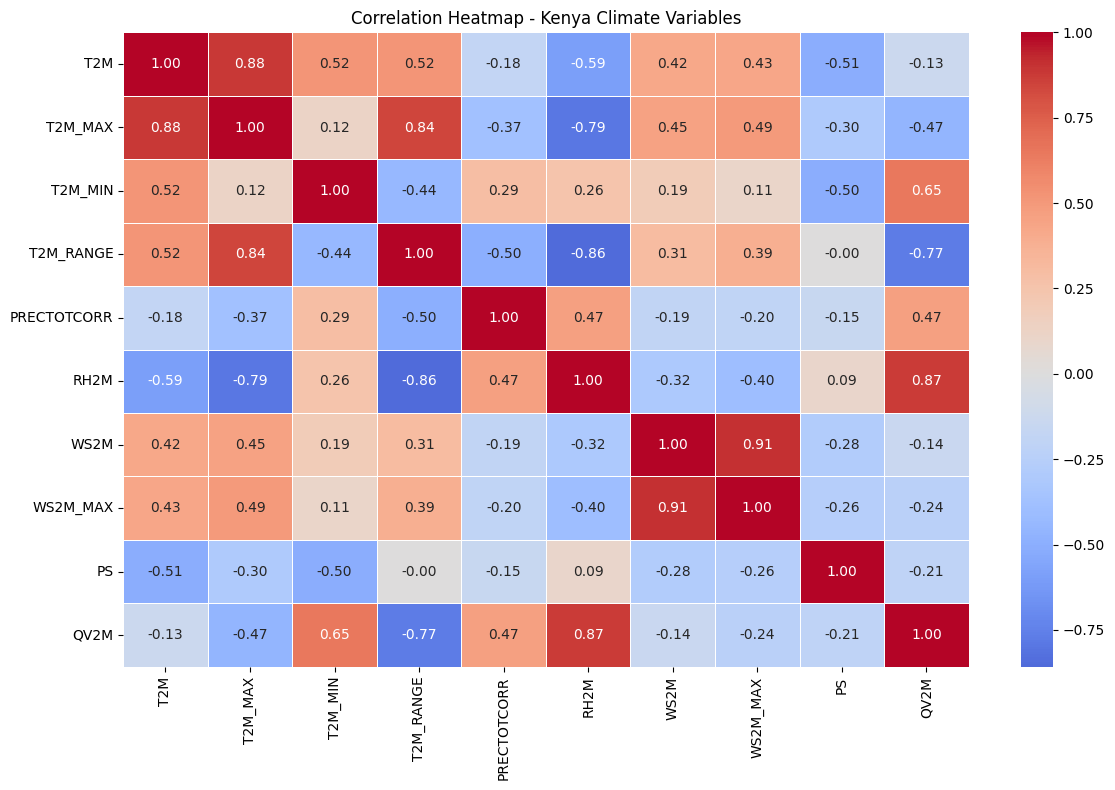

In [9]:
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Kenya Climate Variables")
plt.tight_layout()
plt.show()

## Correlation Analysis
The heatmap shows how strongly each climate variable relates to others.

The three strongest correlations found are:

1. T2M and QV2M (specific humidity) - strong positive correlation.
   When temperature rises, the air holds more moisture.

2. T2M and RH2M (relative humidity) - negative correlation.
   Higher temperatures reduce relative humidity.

3. T2M_MAX and T2M_MIN - strong positive correlation.
   Days with high maximum temperatures also have higher minimum 
   temperatures showing consistent warming patterns.

These relationships are consistent with Ethiopia and confirm temperature 
is the dominant driver of other climate variables across East Africa.

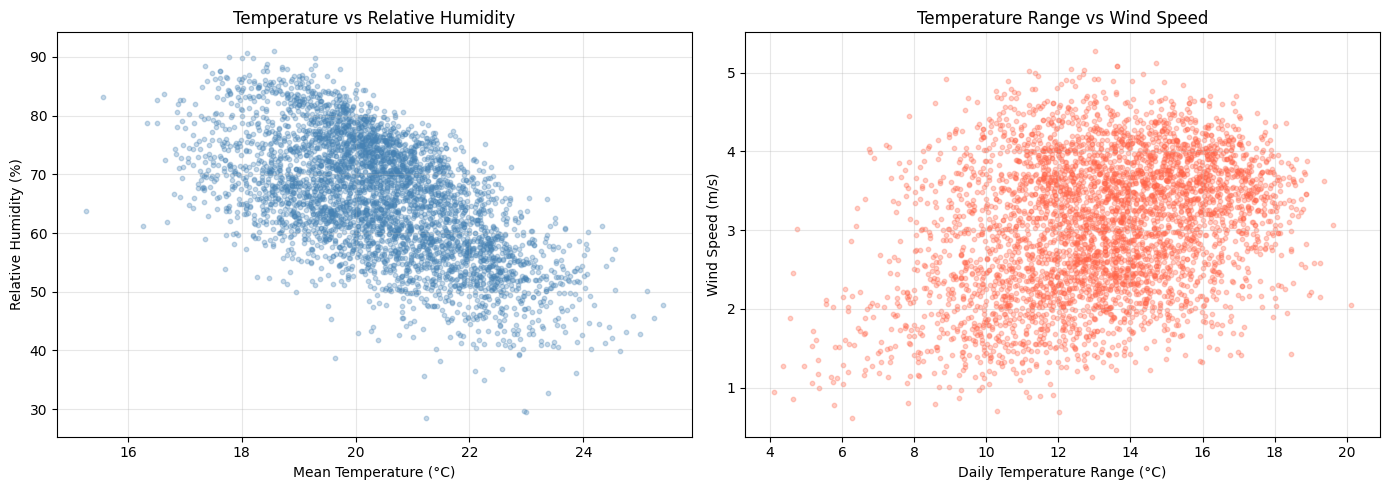

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="steelblue", s=10)
axes[0].set_title("Temperature vs Relative Humidity")
axes[0].set_xlabel("Mean Temperature (°C)")
axes[0].set_ylabel("Relative Humidity (%)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="tomato", s=10)
axes[1].set_title("Temperature Range vs Wind Speed")
axes[1].set_xlabel("Daily Temperature Range (°C)")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter Plot Analysis

Plot 1 - Temperature vs Relative Humidity:
As temperature increases, relative humidity decreases. This is the same 
pattern seen in Ethiopia and confirms a consistent physical relationship 
across East Africa. Warmer air holds more moisture before becoming saturated.

Plot 2 - Temperature Range vs Wind Speed:
A weak positive relationship exists between daily temperature range and 
wind speed. Higher wind days tend to have larger swings between daytime 
and nighttime temperatures.

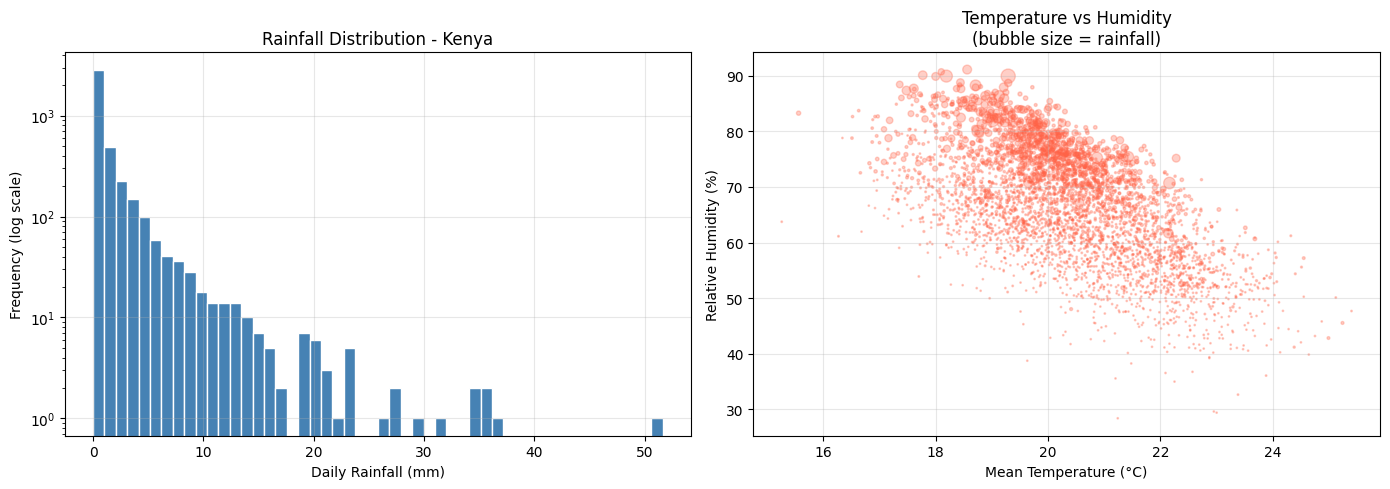

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rainfall histogram
axes[0].hist(df["PRECTOTCORR"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Rainfall Distribution - Kenya")
axes[0].set_xlabel("Daily Rainfall (mm)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].grid(True, alpha=0.3)

# Bubble chart
axes[1].scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"] * 2 + 1, alpha=0.3, color="tomato")
axes[1].set_title("Temperature vs Humidity\n(bubble size = rainfall)")
axes[1].set_xlabel("Mean Temperature (°C)")
axes[1].set_ylabel("Relative Humidity (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution Analysis

Rainfall Histogram:
The histogram shows rainfall is heavily right-skewed. The vast majority 
of days have zero or very low rainfall. Only a small number of days 
experience heavy rainfall above 20mm. This pattern confirms that Kenya's 
rainfall comes in short intense bursts rather than steady amounts 
throughout the year.

Bubble Chart:
Large bubbles (heavy rain days) cluster where humidity is high (70-90%) 
and temperature is moderate (18-21°C). Very hot dry days show small 
bubbles confirming little or no rainfall during those periods. This 
pattern is very similar to Ethiopia showing a consistent East African 
climate signature.